In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import mlflow
import mlflow.pytorch
from typing import Dict, List, Tuple
from tqdm.notebook import tqdm

from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer
from pytorch_forecasting.data import NaNLabelEncoder
from torch.utils.data import DataLoader

from training.data_loading import *
from training.loss_funcs import *

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device           : {DEVICE}")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'
Device           : cuda


In [2]:
weather_cols_all = [
    'temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m',
    'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low',
    'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure',
    'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m',
    'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance'
]

other_cols = [
    'dam_price', 'buy_bm_price', 'sell_bm_price',
    'max_power', 'max_solar', 'max_ev'
]

cat_columns = [
    'eic_code', 'dso_desc', 'station_type', 'oblast',
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

static_cols = [
    'latitude', 'longitude', 'eic_code', 'dso_desc', 'station_type', 'oblast'
]

calendar_cols = [
    'Month', 'Day', 'Hour', 'day_of_week', 'season'
]

time_cols = ['datetime', 'time_idx']

FUTURE_REALS = weather_cols_all + calendar_cols + other_cols
# static reals (numeric only)
STATIC_REALS = ['latitude', 'longitude']
# static categoricals
STATIC_CATS  = ['dso_desc', 'station_type', 'oblast']
# time-varying categoricals
TIME_VAR_CATS = ['Month', 'Day', 'Hour', 'day_of_week', 'season']

print(f"y col is: {Y_COL}, group col is: {GROUP_COL}")
print(f"future reals ({len(FUTURE_REALS)}): {FUTURE_REALS}")

y col is: sum_of_kWh, group col is: eic_code
future reals (29): ['temperature_2m', 'apparent_temperature', 'dew_point_2m', 'relative_humidity_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'direct_normal_irradiance', 'Month', 'Day', 'Hour', 'day_of_week', 'season', 'dam_price', 'buy_bm_price', 'sell_bm_price', 'max_power', 'max_solar', 'max_ev']


In [3]:
print("Loading train â€¦")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)

print("Loading val   â€¦")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  â€¦")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"train: {train.shape}")
print(f"val  : {val.shape}")
print(f"test : {test.shape}")

Loading train â€¦
Loading val   â€¦
Loading test  â€¦
train: (4586151, 38)
val  : (293880, 38)
test : (295430, 38)


In [4]:
# # Uncomment to subsample stations if training is too slow
# TARGET_STATIONS = 395
# station_stats = (
#     train.groupby(GROUP_COL)
#     .agg(rows=(Y_COL, "count"))
#     .reset_index()
#     .sort_values("rows", ascending=False)
# )
# sampled_stations = station_stats.sample(
#     n=TARGET_STATIONS, random_state=42
# )[GROUP_COL].values
# print(f"Stations: {len(sampled_stations)}")
# train = train[train[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# val   = val[val[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# test  = test[test[GROUP_COL].isin(sampled_stations)].reset_index(drop=True)
# print(f"Train rows : {len(train):,}")
# print(f"Val rows   : {len(val):,}")
# print(f"Test rows  : {len(test):,}")

In [5]:
training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617


In [6]:
# â”€â”€ Hyperparameters â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
MAX_ENCODER_LENGTH = 168   # 1 week of hourly history as context
MAX_PREDICTION_LENGTH = 48 # 48-hour forecast horizon

BATCH_SIZE   = 128
NUM_WORKERS  = 4
MAX_EPOCHS   = 30
LEARNING_RATE = 1e-3
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.1

print(f"Encoder length  : {MAX_ENCODER_LENGTH} hours")
print(f"Prediction length: {MAX_PREDICTION_LENGTH} hours")

Encoder length  : 168 hours
Prediction length: 48 hours


In [8]:
# Build price lookup dict from all splits (prices depend only on time_idx/datetime)
all_data = pd.concat([train, val, test], ignore_index=True)
price_lookup = (
    all_data
    .drop_duplicates("time_idx")
    .set_index("time_idx")[["dam_price", "sell_bm_price", "buy_bm_price"]]
    .apply(tuple, axis=1)
    .to_dict()
)
print(f"Price lookup entries: {len(price_lookup):,}")

Price lookup entries: 14,618


In [9]:
class MoneyLoss(nn.Module):
    """
    Differentiable surrogate of money() for use as a PyTorch training loss.

    Prices are looked up from a precomputed dict keyed by time_idx so that
    the DataLoader only needs to return y and time_idx in each batch.
    The dict is built once from the full concatenated train+val+test frames.
    """

    def __init__(self, price_lookup: Dict[int, Tuple[float, float, float]]):
        """
        price_lookup: {time_idx -> (dam_price, sell_bm_price, buy_bm_price)}
        """
        super().__init__()
        # store as tensors for fast indexing
        max_idx = max(price_lookup.keys()) + 1
        dam   = torch.zeros(max_idx)
        sell  = torch.zeros(max_idx)
        buy   = torch.zeros(max_idx)
        for idx, (d, s, b) in price_lookup.items():
            dam[idx]  = d
            sell[idx] = s
            buy[idx]  = b
        self.register_buffer("dam",  dam)
        self.register_buffer("sell", sell)
        self.register_buffer("buy",  buy)

    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor,
                time_idx: torch.Tensor) -> torch.Tensor:
        """
        y_pred, y_true : (batch, horizon)
        time_idx       : (batch, horizon)  â€” the global time index of every step
        """
        flat_idx = time_idx.long().reshape(-1)
        price    = self.dam[flat_idx].reshape_as(y_pred)  / 1000.0
        sell_p   = self.sell[flat_idx].reshape_as(y_pred) / 1000.0
        buy_p    = self.buy[flat_idx].reshape_as(y_pred)  / 1000.0

        ordered  = y_pred * price
        diff     = y_pred - y_true
        real_spend = (
            ordered
            - torch.where(diff > 0, sell_p * diff,  torch.zeros_like(diff))
            - torch.where(diff < 0, buy_p  * diff,  torch.zeros_like(diff))
        )
        min_spend = y_true * price
        return (real_spend - min_spend).sum()/(min_spend.sum()/100)


# ── Sanity check: MoneyLoss (differentiable PyTorch) vs money_pct (numpy) ──
# Use a few random rows from the train frame so the time_idx values are real.
_check_n = 1024
_check_df = train.sample(n=_check_n, random_state=0)
_y_true_np = _check_df[Y_COL].values.astype(np.float32)
# fake some predictions: ground truth scaled by random factor in [0.8, 1.2]
_rng = np.random.default_rng(0)
_y_pred_np = _y_true_np * _rng.uniform(0.8, 1.2, size=_check_n).astype(np.float32)
_dam_np    = _check_df["dam_price"].values.astype(np.float32)
_sell_np   = _check_df["sell_bm_price"].values.astype(np.float32)
_buy_np    = _check_df["buy_bm_price"].values.astype(np.float32)
_tidx_np   = _check_df["time_idx"].values.astype(np.int64)

# numpy reference from loss_funcs
_ref = money_pct(_y_true_np, _y_pred_np, _dam_np, _sell_np, _buy_np)

# pytorch MoneyLoss with the same inputs (single "batch" of horizon=N)
_tmp_loss = MoneyLoss(price_lookup)
_y_pred_t = torch.tensor(_y_pred_np).unsqueeze(0)   # (1, N)
_y_true_t = torch.tensor(_y_true_np).unsqueeze(0)   # (1, N)
_tidx_t   = torch.tensor(_tidx_np).unsqueeze(0)     # (1, N)
_torch_val = _tmp_loss(_y_pred_t, _y_true_t, _tidx_t).item()

print(f"money_pct (numpy reference) : {_ref:.6f}")
print(f"MoneyLoss (torch surrogate) : {_torch_val:.6f}")
print(f"abs diff                    : {abs(_ref - _torch_val):.2e}")
assert abs(_ref - _torch_val) < 1e-3, "MoneyLoss disagrees with money_pct!"
print("✓ MoneyLoss matches money_pct on sample data.")

money_pct (numpy reference) : 3.649402
MoneyLoss (torch surrogate) : 3.649401
abs diff                    : 3.86e-07
✓ MoneyLoss matches money_pct on sample data.


In [10]:
# The dataset uses training_cutoff to split internally.
full_train_val = pd.concat([train, val], ignore_index=True)

# Ensure cat columns are strings (pytorch-forecasting requirement)
for col in cat_columns:
    for df in [full_train_val, test]:
        df[col] = df[col].astype(str)


train_dataset = TimeSeriesDataSet(
    full_train_val[full_train_val.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=Y_COL,
    group_ids=[GROUP_COL],
    min_encoder_length=MAX_ENCODER_LENGTH,   # fixed, same as max
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,  # fixed, same as max
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_reals=STATIC_REALS,
    static_categoricals=STATIC_CATS,
    time_varying_known_reals=[
        c for c in FUTURE_REALS
        if c not in cat_columns and c not in STATIC_REALS
    ],
    time_varying_known_categoricals=TIME_VAR_CATS,
    time_varying_unknown_reals=[Y_COL],
    target_normalizer=GroupNormalizer(
        groups=[GROUP_COL], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

val_dataset = TimeSeriesDataSet.from_dataset(
    train_dataset,
    full_train_val,
    predict=True,
    stop_randomization=True,
)

# Use to_dataloader() so pytorch-forecasting's _collate_fn is used.
# DataLoader(...) with default_collate fails because weight is None
# when no weight column is set in the dataset.
train_loader = train_dataset.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=0
)
val_loader = val_dataset.to_dataloader(
    train=False, batch_size=BATCH_SIZE * 2, num_workers=0
)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")

Train batches : 35,165
Val   batches : 2


In [11]:
class LSTMForecaster(nn.Module):
    """
    LSTM-based multi-step forecaster consuming pytorch-forecasting batch dicts.

    LSTM vs GRU
    -----------
    Compared with GRU (which only carries a single hidden state h_t through time),
    an LSTM cell carries **two** tensors: a hidden state `h_t` and a cell state `c_t`.
    The cell state acts as a longer-term memory regulated by the input/forget/output
    gates, which is generally more expressive on long sequences than GRU's update
    gate alone. This is why LSTM tends to do better than GRU when the sequence
    contains long-range dependencies (e.g. weekly seasonality across 168 hourly
    steps in this dataset).

    For the encoder–decoder architecture below we therefore have to:
      * derive BOTH `h0` and `c0` from the static context (instead of just `h0`),
      * forward both states through `nn.LSTM` (which expects/returns a `(h, c)`
        tuple as the hidden state argument), and
      * pass the encoder's `(h_n, c_n)` to the decoder so the temporal context
        from the look-back window flows into the forecast horizon.

    Tensor shapes (batch_first=True)
    --------------------------------
    encoder input  : (B, T_enc, encoder_input_size)
    decoder input  : (B, T_dec, decoder_input_size)
    h0 / c0        : (num_layers, B, hidden_size)   <- LSTM needs both
    h_n / c_n      : (num_layers, B, hidden_size)   <- LSTM returns both
    decoder output : (B, T_dec, hidden_size)
    final output   : (B, T_dec)                     <- one regression value per step

    pytorch-forecasting packs ALL categoricals into encoder_cat / decoder_cat in the order
    [static_cats, tv_known_cats] (group_ids are in x["groups"], not here).
    ALL reals go into encoder_cont in the order [target, static_reals, tv_known_reals, ..., extras].
    decoder_cont has the same columns as encoder_cont.

    We receive the column positions of static / tv features as index buffers
    so the forward pass can slice the right columns without hard-coding offsets.
    """

    def __init__(
        self,
        n_cont_encoder: int,
        n_cont_decoder: int,
        cat_embedding_dims: List[Tuple[int, int]],       # TV cat (vocab, emb_dim)
        static_real_dim: int,
        static_cat_embedding_dims: List[Tuple[int, int]], # static cat (vocab, emb_dim)
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout: float = 0.1,
        prediction_length: int = 48,
        static_real_idx: List[int] = None,  # positions of static reals in encoder_cont
        static_cat_idx:  List[int] = None,  # positions of static cats  in encoder_cat
        tv_cat_idx_enc:  List[int] = None,  # positions of TV    cats  in encoder_cat / decoder_cat
    ):
        super().__init__()
        self.prediction_length = prediction_length
        self.num_layers        = num_layers
        self.hidden_size       = hidden_size

        # ── Embeddings ───────────────────────────────────────────────────────
        self.tv_cat_embeddings = nn.ModuleList([
            nn.Embedding(vocab, dim) for vocab, dim in cat_embedding_dims
        ])
        self.static_cat_embeddings = nn.ModuleList([
            nn.Embedding(vocab, dim) for vocab, dim in static_cat_embedding_dims
        ])

        tv_emb_dim     = sum(d for _, d in cat_embedding_dims)
        static_emb_dim = sum(d for _, d in static_cat_embedding_dims)

        encoder_input_size = n_cont_encoder + tv_emb_dim
        decoder_input_size = n_cont_decoder + tv_emb_dim
        static_input_size  = static_real_dim + static_emb_dim

        # Static context projection → initial (hidden, cell) state.
        # LSTM needs BOTH h0 and c0, so we project into 2 * hidden_size * num_layers
        # and split the output. (For GRU only hidden_size * num_layers was needed.)
        self.static_proj = nn.Linear(
            static_input_size, 2 * hidden_size * num_layers
        )

        # ── Encoder LSTM ────────────────────────────────────────────────────
        # nn.LSTM signature is identical to nn.GRU except for the hidden-state
        # tuple (h, c) that flows through the gates.
        self.encoder_lstm = nn.LSTM(
            input_size=encoder_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # ── Decoder LSTM ────────────────────────────────────────────────────
        self.decoder_lstm = nn.LSTM(
            input_size=decoder_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc_out  = nn.Linear(hidden_size, 1)

        # Index buffers – moved to the right device automatically with .to(device)
        self.register_buffer("static_real_idx", torch.tensor(static_real_idx or [], dtype=torch.long))
        self.register_buffer("static_cat_idx",  torch.tensor(static_cat_idx  or [], dtype=torch.long))
        self.register_buffer("tv_cat_idx_enc",  torch.tensor(tv_cat_idx_enc  or [], dtype=torch.long))

    def _embed_tv_cats(self, cat_tensor: torch.Tensor) -> torch.Tensor:
        """cat_tensor: (B, T, n_cat_tv) → (B, T, total_emb_dim)"""
        parts = [
            emb(cat_tensor[..., i].clamp(0, emb.num_embeddings - 1))
            for i, emb in enumerate(self.tv_cat_embeddings)
        ]
        return torch.cat(parts, dim=-1) if parts else torch.zeros(
            cat_tensor.shape[0], cat_tensor.shape[1], 0, device=cat_tensor.device
        )

    def _embed_static_cats(self, cat_tensor: torch.Tensor) -> torch.Tensor:
        """cat_tensor: (B, n_static_cat) → (B, total_emb_dim)"""
        parts = [
            emb(cat_tensor[:, i].clamp(0, emb.num_embeddings - 1))
            for i, emb in enumerate(self.static_cat_embeddings)
        ]
        return torch.cat(parts, dim=-1) if parts else torch.zeros(
            cat_tensor.shape[0], 0, device=cat_tensor.device
        )

    def _init_states(self, static_inp: torch.Tensor):
        """
        Build (h0, c0) for the LSTM from the static context vector.

        static_inp : (B, static_input_size)
        returns    : (h0, c0) each of shape (num_layers, B, hidden_size)
        """
        proj = self.static_proj(static_inp)                         # (B, 2*H*L)
        proj = proj.view(proj.shape[0], self.num_layers, 2, self.hidden_size)
        # split last-but-one dim into h, c
        h0 = proj[:, :, 0, :].permute(1, 0, 2).contiguous()         # (L, B, H)
        c0 = proj[:, :, 1, :].permute(1, 0, 2).contiguous()         # (L, B, H)
        return h0, c0

    def forward(self, x: Dict[str, torch.Tensor]) -> torch.Tensor:
        enc_cont = x["encoder_cont"]   # (B, T_enc, n_all_reals)
        dec_cont = x["decoder_cont"]   # (B, T_dec, n_all_reals)
        enc_cat  = x["encoder_cat"]    # (B, T_enc, n_static+n_tv) – static_cats + tv_known
        dec_cat  = x["decoder_cat"]    # (B, T_dec, n_static+n_tv) – same columns as encoder_cat

        # ── Static features (constant → take first encoder timestep) ──────
        static_cat_raw = enc_cat[:, 0, self.static_cat_idx]    # (B, n_static_cat)
        static_cat_emb = self._embed_static_cats(static_cat_raw)
        static_real    = enc_cont[:, 0, self.static_real_idx]   # (B, n_static_real)
        static_inp     = torch.cat([static_real, static_cat_emb], dim=-1)

        # LSTM-specific: derive BOTH initial hidden state and cell state.
        h0, c0 = self._init_states(static_inp)

        # ── Encoder ────────────────────────────────────────────────────────
        enc_tv_cat = enc_cat[..., self.tv_cat_idx_enc]              # (B, T_enc, n_tv_cat)
        enc_emb    = self._embed_tv_cats(enc_tv_cat)
        enc_inp    = torch.cat([enc_cont, enc_emb], dim=-1)
        # nn.LSTM returns (output, (h_n, c_n)) — we need both states for the decoder
        _, (h_n, c_n) = self.encoder_lstm(enc_inp, (h0, c0))

        # ── Decoder ────────────────────────────────────────────────────────
        # decoder_cat has the same column layout as encoder_cat; slice TV cats
        dec_tv_cat = dec_cat[..., self.tv_cat_idx_enc]              # (B, T_dec, n_tv_cat)
        dec_emb    = self._embed_tv_cats(dec_tv_cat)
        dec_inp    = torch.cat([dec_cont, dec_emb], dim=-1)
        # Pass the encoder's (h_n, c_n) tuple as the decoder's initial state
        dec_out, _ = self.decoder_lstm(dec_inp, (h_n, c_n))

        return self.fc_out(self.dropout(dec_out)).squeeze(-1)       # (B, T_dec)

In [12]:
def suggest_embedding_dim(vocab_size: int) -> int:
    return min(50, max(4, vocab_size // 2))

cat_encoders = train_dataset.get_parameters()["categorical_encoders"]

def get_vocab_size(col):
    enc = cat_encoders[col]
    return len(enc.classes_) + 1

tv_cat_dims = [
    (get_vocab_size(col), suggest_embedding_dim(get_vocab_size(col)))
    for col in train_dataset.time_varying_known_categoricals
]

static_cat_dims = [
    (get_vocab_size(col), suggest_embedding_dim(get_vocab_size(col)))
    for col in train_dataset.static_categoricals
]

n_cont_encoder  = len(train_dataset.reals)
n_cont_decoder  = n_cont_encoder   # decoder_cont.shape[-1] == encoder_cont.shape[-1]
static_real_dim = len(train_dataset.static_reals)

# encoder_cat column order matches flat_categoricals:
#   static_categoricals + tv_known_categoricals  (group_ids are in x["groups"], NOT here)
all_cats_enc = (
    list(train_dataset.static_categoricals) +
    list(train_dataset.time_varying_known_categoricals)
)
static_cat_idx = [all_cats_enc.index(c) for c in train_dataset.static_categoricals]
tv_cat_idx_enc = [all_cats_enc.index(c) for c in train_dataset.time_varying_known_categoricals]

# encoder_cont column order matches train_dataset.reals
all_reals       = list(train_dataset.reals)
static_real_idx = [all_reals.index(c) for c in train_dataset.static_reals]

print(f"encoder_cat columns ({len(all_cats_enc)}): {all_cats_enc}")
print(f"static_cat_idx  : {static_cat_idx}  -> {[all_cats_enc[i] for i in static_cat_idx]}")
print(f"tv_cat_idx_enc  : {tv_cat_idx_enc}  -> {[all_cats_enc[i] for i in tv_cat_idx_enc]}")
print(f"encoder_cont (first 5): {all_reals[:5]}")
print(f"static_real_idx : {static_real_idx}  -> {[all_reals[i] for i in static_real_idx]}")
print(f"n_cont_enc/dec  : {n_cont_encoder}")

# LSTM replaces GRU here. The constructor signature is identical, but the
# class internally manages BOTH the hidden state h and the cell state c.
model = LSTMForecaster(
    n_cont_encoder=n_cont_encoder,
    n_cont_decoder=n_cont_decoder,
    cat_embedding_dims=tv_cat_dims,
    static_real_dim=static_real_dim,
    static_cat_embedding_dims=static_cat_dims,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    prediction_length=MAX_PREDICTION_LENGTH,
    static_real_idx=static_real_idx,
    static_cat_idx=static_cat_idx,
    tv_cat_idx_enc=tv_cat_idx_enc,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters : {total_params:,}")
print(model)

encoder_cat columns (8): ['dso_desc', 'station_type', 'oblast', 'Month', 'Day', 'Hour', 'day_of_week', 'season']
static_cat_idx  : [0, 1, 2]  -> ['dso_desc', 'station_type', 'oblast']
tv_cat_idx_enc  : [3, 4, 5, 6, 7]  -> ['Month', 'Day', 'Hour', 'day_of_week', 'season']
encoder_cont (first 5): ['latitude', 'longitude', 'encoder_length', 'sum_of_kWh_center', 'sum_of_kWh_scale']
static_real_idx : [0, 1]  -> ['latitude', 'longitude']
n_cont_enc/dec  : 31
Model parameters : 490,743
LSTMForecaster(
  (tv_cat_embeddings): ModuleList(
    (0): Embedding(13, 6)
    (1): Embedding(32, 16)
    (2): Embedding(25, 12)
    (3): Embedding(8, 4)
    (4): Embedding(5, 4)
  )
  (static_cat_embeddings): ModuleList(
    (0): Embedding(28, 14)
    (1): Embedding(8, 4)
    (2): Embedding(24, 12)
  )
  (static_proj): Linear(in_features=32, out_features=512, bias=True)
  (encoder_lstm): LSTM(73, 128, num_layers=2, batch_first=True, dropout=0.1)
  (decoder_lstm): LSTM(73, 128, num_layers=2, batch_first=True,

In [13]:
def inverse_softplus(y_norm: torch.Tensor, target_scale: torch.Tensor) -> torch.Tensor:
    """Undo GroupNormalizer(transformation='softplus'): y_abs = softplus(y_norm * scale) """
    center = target_scale[:, 0].unsqueeze(1)   # mean  (B, 1)
    scale  = target_scale[:, 1].unsqueeze(1)   # std   (B, 1)
    return torch.nn.functional.softplus(y_norm * scale + center)

In [14]:
import math

money_loss_fn = MoneyLoss(price_lookup).to(DEVICE)
optimizer     = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, verbose=True
)

# Combined loss = money_pct + SMAPE_WEIGHT * smape
# - money_pct comes from MoneyLoss (already differentiable, business-aligned)
# - SMAPE adds a symmetric, scale-free regulariser that discourages
#   the optimiser from collapsing to degenerate solutions (e.g. always
#   over-buying when sell_bm_price is small) and stabilises training.
SMAPE_WEIGHT = 0.2


def smape_torch(y_pred: torch.Tensor, y_true: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """Differentiable SMAPE on a (B, H) batch in absolute units. Range: 0..2."""
    abs_diff = (y_pred - y_true).abs()
    denom    = (y_pred.abs() + y_true.abs()).clamp_min(eps)
    return (2.0 * abs_diff / denom).mean()


mlflow.set_experiment("lstm_energy_forecast")

# Make sure the checkpoint directory exists
import os
os.makedirs("../models/lstm", exist_ok=True)
CKPT_PATH = "../models/lstm/best_lstm_fixed_time_idx.pt"


with mlflow.start_run(run_name="lstm_money_loss"):
    # Architecture & training config
    mlflow.log_params({
        "model":                  "LSTM",
        "hidden_size":            HIDDEN_SIZE,
        "num_layers":             NUM_LAYERS,
        "dropout":                DROPOUT,
        "max_encoder_length":     MAX_ENCODER_LENGTH,
        "max_prediction_length":  MAX_PREDICTION_LENGTH,
        "batch_size":             BATCH_SIZE,
        "learning_rate":          LEARNING_RATE,
        "max_epochs":             MAX_EPOCHS,
        "loss":                   f"MoneyLoss + {SMAPE_WEIGHT} * SMAPE",
        "smape_weight":           SMAPE_WEIGHT,
        "total_params":           sum(p.numel() for p in model.parameters() if p.requires_grad),
    })
    # Dataset / feature info
    mlflow.log_params({
        "train_rows":             len(train),
        "val_rows":               len(val),
        "test_rows":               len(test),
        "n_stations":             train[GROUP_COL].nunique(),
        "train_date_min":         str(train["datetime"].min()),
        "train_date_max":         str(train["datetime"].max()),
        "val_date_min":           str(val["datetime"].min()),
        "val_date_max":           str(val["datetime"].max()),
        "test_date_min":          str(test["datetime"].min()),
        "test_date_max":          str(test["datetime"].max()),
        "future_reals":           ",".join(FUTURE_REALS),
        "static_reals":           ",".join(STATIC_REALS),
        "static_cats":            ",".join(STATIC_CATS),
        "tv_cats":                ",".join(TIME_VAR_CATS),
        "y_col":                  Y_COL,
        "group_col":              GROUP_COL,
    })

    best_val_loss = float("inf")

    for epoch in range(1, MAX_EPOCHS + 1):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        train_combined_total = 0.0
        # accumulators for printable train money_pct / smape
        tr_sum_smape = 0.0
        tr_sum_money_w = 0.0   # money_pct weighted by batch elements
        tr_n_elem    = 0
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [train]", leave=False)

        for x, (y, weight) in train_bar:
            x            = {k: v.to(DEVICE) for k, v in x.items()}
            y            = y.to(DEVICE)
            time_idx_dec = x["decoder_time_idx"]
            target_scale = x["target_scale"]

            optimizer.zero_grad()
            # LSTM forward — internally manages (h, c) hidden+cell state pair.
            # Output shape: (B, T_dec)
            y_pred = model(x)

            # Denormalise to absolute kWh for MoneyLoss / SMAPE
            y_pred_denorm = inverse_softplus(y_pred, target_scale)
            y_denorm      = inverse_softplus(y,      target_scale)

            money_pct_loss = money_loss_fn(y_pred_denorm, y_denorm, time_idx_dec)
            smape_loss     = smape_torch(y_pred_denorm, y_denorm)
            loss           = money_pct_loss + SMAPE_WEIGHT * smape_loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_combined_total += loss.item()
            n_b = y_denorm.numel()
            tr_sum_smape   += smape_loss.item() * n_b
            tr_sum_money_w += money_pct_loss.item() * n_b
            tr_n_elem      += n_b
            train_bar.set_postfix({
                "loss":  f"{loss.item():.2f}",
                "pct":   f"{money_pct_loss.item():.2f}",
                "smape": f"{smape_loss.item():.4f}",
            })

        avg_train_loss     = train_combined_total / len(train_loader)
        train_money_pct    = tr_sum_money_w / tr_n_elem if tr_n_elem else float("nan")
        train_smape        = tr_sum_smape   / tr_n_elem if tr_n_elem else float("nan")

        # ── Validate ──────────────────────────────────────────────────────
        model.eval()
        val_combined_total = 0.0
        # accumulators for absolute-unit metrics
        sum_sq_err    = 0.0
        sum_pct_err   = 0.0
        sum_smape     = 0.0
        sum_money_w   = 0.0
        n_elem        = 0
        sum_pred      = 0.0
        sum_true      = 0.0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS} [val]  ", leave=False)
            for x, (y, weight) in val_bar:
                x            = {k: v.to(DEVICE) for k, v in x.items()}
                y            = y.to(DEVICE)
                time_idx_dec = x["decoder_time_idx"]
                target_scale = x["target_scale"]

                y_pred = model(x)
                y_pred_denorm = inverse_softplus(y_pred, target_scale)
                y_denorm      = inverse_softplus(y,      target_scale)

                money_pct_loss = money_loss_fn(y_pred_denorm, y_denorm, time_idx_dec)
                smape_loss     = smape_torch(y_pred_denorm, y_denorm)
                loss           = money_pct_loss + SMAPE_WEIGHT * smape_loss
                val_combined_total += loss.item()

                # additional diagnostics in absolute units
                diff     = y_pred_denorm - y_denorm
                abs_diff = diff.abs()
                eps      = 1e-8
                sum_sq_err  += (diff ** 2).sum().item()
                sum_pct_err += (abs_diff / y_denorm.abs().clamp_min(eps)).sum().item()
                denom        = (y_pred_denorm.abs() + y_denorm.abs()).clamp_min(eps)
                sum_smape   += (2.0 * abs_diff / denom).sum().item()
                n_b          = y_denorm.numel()
                sum_money_w += money_pct_loss.item() * n_b
                n_elem      += n_b
                sum_pred    += y_pred_denorm.sum().item()
                sum_true    += y_denorm.sum().item()

        avg_val_loss = val_combined_total / len(val_loader)
        scheduler.step(avg_val_loss)

        if n_elem > 0:
            val_rmse      = math.sqrt(sum_sq_err / n_elem)
            val_mape      = (sum_pct_err / n_elem) * 100.0
            val_smape     = sum_smape / n_elem
            val_money_pct = sum_money_w / n_elem
            val_bias      = sum_pred - sum_true
        else:
            val_rmse = val_mape = val_smape = val_money_pct = val_bias = float("nan")

        mlflow.log_metrics({
            "train_combined_loss": avg_train_loss,
            "train_money_pct":     train_money_pct,
            "train_smape":         train_smape,
            "val_combined_loss":   avg_val_loss,
            "val_money_pct":       val_money_pct,
            "val_rmse":            val_rmse,
            "val_mape":            val_mape,
            "val_smape":           val_smape,
            "val_pred_bias":       val_bias,
            "lr":                  optimizer.param_groups[0]["lr"],
        }, step=epoch)

        print(
            f"Epoch {epoch:>3}/{MAX_EPOCHS}  "
            f"train_pct={train_money_pct:.3f}% train_smape={train_smape:.3f}  "
            f"val_pct={val_money_pct:.3f}% val_smape={val_smape:.3f}  "
            f"val_rmse={val_rmse:.2f}  val_mape={val_mape:.2f}%  bias={val_bias:+.1f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), CKPT_PATH)
            mlflow.log_artifact(CKPT_PATH)
            print(f"  ✓ new best val_combined_loss={best_val_loss:.4f} → checkpoint saved")

print("Training complete.")
print(f"Best val combined loss : {best_val_loss:.4f}")

Epoch 1/30 [train]:   0%|          | 0/35165 [00:00<?, ?it/s]

Epoch 1/30 [val]  :   0%|          | 0/2 [00:00<?, ?it/s]

Epoch   1/30  train_pct=0.457% train_smape=0.046  val_pct=35.733% val_smape=0.794  val_rmse=382.23  val_mape=265.40%  bias=+679524.9
  ✓ new best val_combined_loss=35.9119 → checkpoint saved


Epoch 2/30 [train]:   0%|          | 0/35165 [00:00<?, ?it/s]

Epoch 2/30 [val]  :   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 17/30 [train]:   0%|          | 0/35165 [00:00<?, ?it/s]

Epoch 17/30 [val]  :   0%|          | 0/2 [00:00<?, ?it/s]

Epoch  17/30  train_pct=-0.708% train_smape=0.023  val_pct=21.376% val_smape=1.407  val_rmse=360.73  val_mape=95.18%  bias=-479610.0


Epoch 18/30 [train]:   0%|          | 0/35165 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [15]:
model.load_state_dict(torch.load("../models/lstm/best_lstm_fixed_time_idx.pt", map_location=DEVICE))
model.eval()

LSTMForecaster(
  (tv_cat_embeddings): ModuleList(
    (0): Embedding(13, 6)
    (1): Embedding(32, 16)
    (2): Embedding(25, 12)
    (3): Embedding(8, 4)
    (4): Embedding(5, 4)
  )
  (static_cat_embeddings): ModuleList(
    (0): Embedding(28, 14)
    (1): Embedding(8, 4)
    (2): Embedding(24, 12)
  )
  (static_proj): Linear(in_features=32, out_features=512, bias=True)
  (encoder_lstm): LSTM(73, 128, num_layers=2, batch_first=True, dropout=0.1)
  (decoder_lstm): LSTM(73, 128, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_out): Linear(in_features=128, out_features=1, bias=True)
)

In [16]:
def inverse_softplus(y_norm: torch.Tensor, target_scale: torch.Tensor) -> torch.Tensor:
    center = target_scale[:, 0].unsqueeze(1)
    scale  = target_scale[:, 1].unsqueeze(1)
    return torch.nn.functional.softplus(y_norm * scale + center)


def rolling_predict(
    df: pd.DataFrame,
    dataset_ref: TimeSeriesDataSet,
    horizon: int = MAX_PREDICTION_LENGTH,
) -> pd.DataFrame:
    records = []
    model.eval()

    for grp, gdf in tqdm(df.groupby(GROUP_COL), desc="Stations"):
        gdf   = gdf.sort_values("time_idx").reset_index(drop=True)
        start = gdf["time_idx"].min()
        end   = gdf["time_idx"].max()

        while start <= end:
            enc_start = start - MAX_ENCODER_LENGTH
            dec_end   = start + horizon - 1

            window_df = gdf[
                (gdf["time_idx"] >= enc_start) &
                (gdf["time_idx"] <= dec_end)
            ].reset_index(drop=True)

            # Need full encoder + at least 1 decoder step
            if len(window_df) < MAX_ENCODER_LENGTH + 1:
                start += horizon
                continue

            try:
                # Build a minimal single-row dataset for this window
                # by passing the full df with min_prediction_idx set
                # so pytorch-forecasting selects only this window
                tmp_df = df[
                    (df[GROUP_COL] == grp) &
                    (df["time_idx"] >= enc_start) &
                    (df["time_idx"] <= dec_end)
                ].reset_index(drop=True)

                window_ds = TimeSeriesDataSet.from_dataset(
                    dataset_ref,
                    tmp_df,
                    predict=False,          # ← False avoids predict_mode index bugs
                    stop_randomization=True,
                    min_prediction_idx=start,   # only predict from `start` onward
                )
                loader = window_ds.to_dataloader(
                    train=False, batch_size=64, num_workers=0
                )

                for x, (y_true_batch, _) in loader:
                    target_scale_cpu = x["target_scale"].clone()
                    x = {k: v.to(DEVICE) for k, v in x.items()}

                    with torch.no_grad():
                        y_pred_norm = model(x)

                    y_pred_denorm = inverse_softplus(
                        y_pred_norm, x["target_scale"]
                    ).cpu().numpy()
                    y_true_denorm = inverse_softplus(
                        y_true_batch, target_scale_cpu
                    ).numpy()
                    tidx = x["decoder_time_idx"].cpu().numpy()

                    for b in range(tidx.shape[0]):
                        for t in range(tidx.shape[1]):
                            records.append({
                                GROUP_COL:  grp,
                                "time_idx": int(tidx[b, t]),
                                "pred":     float(y_pred_denorm[b, t]),
                                Y_COL:      float(y_true_denorm[b, t]),
                            })

            except Exception as e:
                pass  # replace with `print(e)` temporarily if still seeing errors

            start += horizon

    result = (
        pd.DataFrame(records)
        .drop_duplicates(subset=[GROUP_COL, "time_idx"])
    )
    meta = df[["time_idx", "datetime", "dam_price", "sell_bm_price", "buy_bm_price"]].drop_duplicates("time_idx")
    return result.merge(meta, on="time_idx", how="left")

for col in cat_columns:
    val[col]  = val[col].astype(str)
    test[col] = test[col].astype(str)

print("Running inference on validation split …")
val_eval = rolling_predict(val, train_dataset)
print(f"val_eval rows : {len(val_eval):,}")

print("Running inference on test split …")
test_eval = rolling_predict(test, train_dataset)
print(f"test_eval rows: {len(test_eval):,}")

Running inference on validation split …


Stations:   0%|          | 0/395 [00:00<?, ?it/s]

val_eval rows : 208,560
Running inference on test split …


Stations:   0%|          | 0/395 [00:00<?, ?it/s]

test_eval rows: 208,560


In [17]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

val_smape_v     = smape(val_eval[Y_COL], val_eval['pred'])
val_rmse_v      = rmse(val_eval[Y_COL], val_eval['pred'])
val_mape_v      = mape(val_eval[Y_COL], val_eval['pred'])
val_money_v     = money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))
val_money_pct_v = money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval))

test_smape_v     = smape(test_eval[Y_COL], test_eval['pred'])
test_rmse_v      = rmse(test_eval[Y_COL], test_eval['pred'])
test_mape_v      = mape(test_eval[Y_COL], test_eval['pred'])
test_money_v     = money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))
test_money_pct_v = money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval))

print("â”€â”€ Validation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {val_smape_v:.4f}")
print(f"RMSE      : {val_rmse_v:.4f}")
print(f"MAPE      : {val_mape_v:.2f} %")
print(f"MONEY     : {val_money_v:.4f}")
print(f"MONEY_PCT : {val_money_pct_v:.4f}%")

print("â”€â”€ Test â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {test_smape_v:.4f}")
print(f"RMSE      : {test_rmse_v:.4f}")
print(f"MAPE      : {test_mape_v:.2f} %")
print(f"MONEY     : {test_money_v:.4f}")
print(f"MONEY_PCT : {test_money_pct_v:.4f}%")

with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_metrics({
        "val_smape":      val_smape_v,
        "val_rmse":       val_rmse_v,
        "val_mape":       val_mape_v,
        "val_money":      val_money_v,
        "val_money_pct":  val_money_pct_v,
        "test_smape":     test_smape_v,
        "test_rmse":      test_rmse_v,
        "test_mape":      test_mape_v,
        "test_money":     test_money_v,
        "test_money_pct": test_money_pct_v,
    })
print(f"MLflow run logged â†’ {mlflow.get_tracking_uri()}")

â”€â”€ Validation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Aligned samples : 208,560
SMAPE     : 195.9667
RMSE      : 567.6471
MAPE      : 103.53 %
MONEY     : 71832275.9754
MONEY_PCT : 36.0265%
â”€â”€ Test â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
Aligned samples : 208,560
SMAPE     : 195.8538
RMSE      : 593.3052
MAPE      : 103.22 %
MONEY     : 50701985.3189
MONEY_PCT : 24.9680%
MLflow run logged â†’ file:///C:/Users/Lev/Documents/GitHub/Diploma/train_models_v2/mlruns


In [18]:
def per_station_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for grp, gdf in eval_df.groupby(GROUP_COL):
        rows.append({
            GROUP_COL:   grp,
            "n":         len(gdf),
            "SMAPE":     smape(gdf[Y_COL], gdf["pred"]),
            "RMSE":      rmse(gdf[Y_COL], gdf["pred"]),
            "MAPE":      mape(gdf[Y_COL], gdf["pred"]),
            "MONEY":     money(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
            "MONEY_PCT": money_pct(gdf[Y_COL], gdf["pred"], *_prices(gdf)),
        })
    return pd.DataFrame(rows).sort_values("SMAPE")


test_station_metrics = per_station_metrics(test_eval)

print("Top-10 best stations (test SMAPE):")
print(test_station_metrics.head(10).to_string(index=False))
print("\nBottom-10 worst stations (test SMAPE):")
print(test_station_metrics.tail(10).to_string(index=False))

Top-10 best stations (test SMAPE):
        eic_code   n      SMAPE       RMSE       MAPE         MONEY  MONEY_PCT
62Z7458705390604 528 173.437929  98.447932  90.915181  70384.158172  24.675836
62Z4272248913477 528 173.519237 106.158520 105.443167  84395.566262  40.431733
62Z7082490910138 528 173.617100 145.111891  90.840412 102517.379153  24.203911
62Z7876545081062 528 176.440675 153.913999  90.371825 106412.676518  23.369605
62Z7401145918482 528 177.489416  63.413113  93.169584  45860.686328  25.402431
62Z5807715983143 528 179.140116 145.246654  92.904160 103758.681639  24.624519
62Z5544769493288 528 179.602317  52.609248  94.358325  38333.524800  25.853601
62Z4948939192262 528 182.046037  35.264077  97.907707  26633.803923  28.683106
62Z4988166368088 528 182.639567  37.397404 102.292154  28677.882001  33.221200
62Z6960657066877 528 184.063987  49.193982  98.319046  36681.577027  28.417147

Bottom-10 worst stations (test SMAPE):
        eic_code   n      SMAPE      RMSE       MAPE    

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(df, eic_code, start_dt=None, end_dt=None, title_prefix=""):
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{title_prefix}{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  MONEY_PCT={money_pct(df[Y_COL], df['pred'], *_prices(df)):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

Best  station (SMAPE): 62Z7458705390604


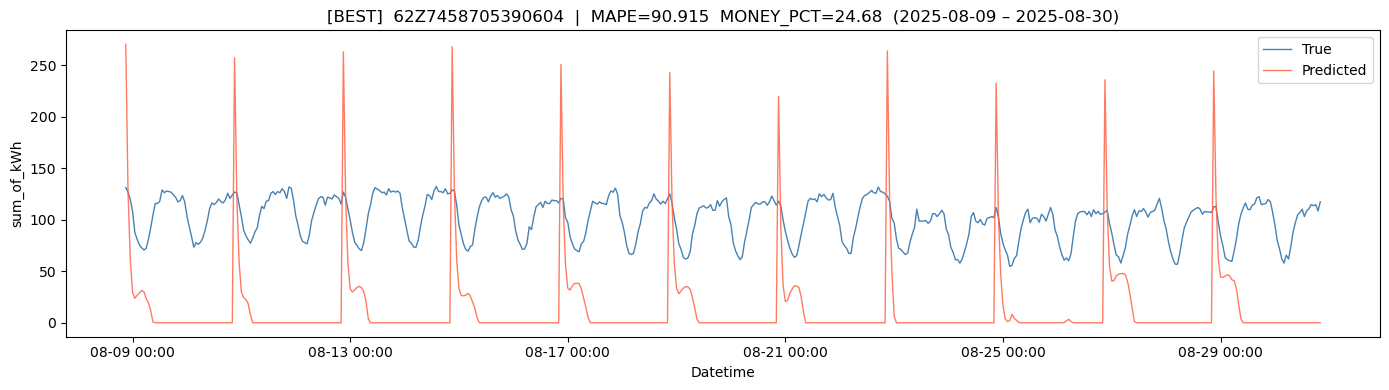

Worst station (SMAPE): 62Z6624735969589


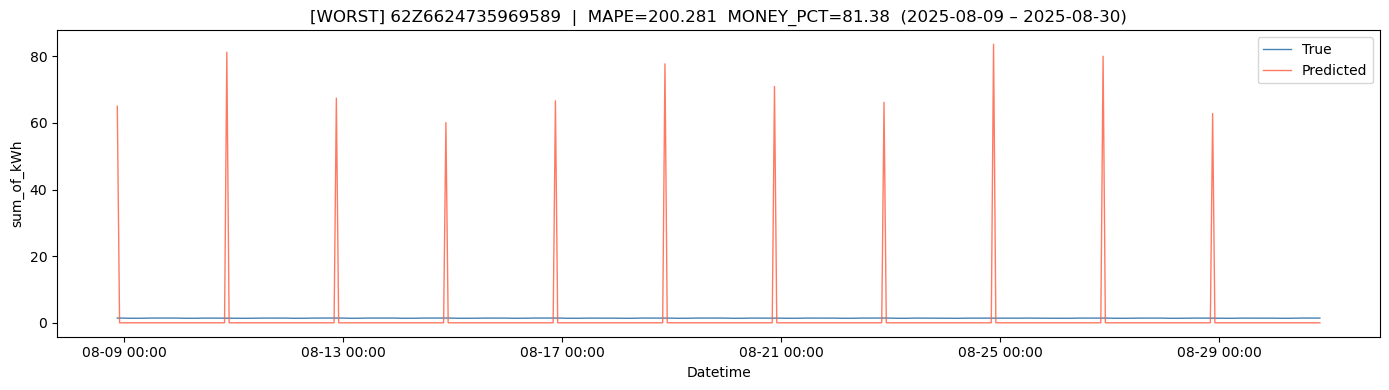

In [20]:
best_station  = test_station_metrics.iloc[0][GROUP_COL]
worst_station = test_station_metrics.iloc[-1][GROUP_COL]

print(f"Best  station (SMAPE): {best_station}")
plot_forecast(test_eval, eic_code=best_station,  title_prefix="[BEST]  ")

print(f"Worst station (SMAPE): {worst_station}")
plot_forecast(test_eval, eic_code=worst_station, title_prefix="[WORST] ")